# Install Dependecies

In [2]:
%%capture
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install python-terrier

In [3]:
# Load java
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null

# check java and version
!which java
!java -version
!readlink -f $(which java)
!ls -la /usr/lib/jvm
!java --version
!javac --version


                                -+syyyyyyys:
                            `/yho:`       -yd.
                         `/yh/`             +m.
                       .oho.                 hy                          .`
                     .sh/`                   :N`                `-/o`  `+dyyo:.
                   .yh:`                     `M-          `-/osysoym  :hs` `-+sys:      hhyssssssssy+
                 .sh:`                       `N:          ms/-``  yy.yh-      -hy.    `.N-````````+N.
               `od/`                         `N-       -/oM-      ddd+`     `sd:     hNNm        -N:
              :do`                           .M.       dMMM-     `ms.      /d+`     `NMMs       `do
            .yy-                             :N`    ```mMMM.      -      -hy.       /MMM:       yh
          `+d+`           `:/oo/`       `-/osyh/ossssssdNMM`           .sh:         yMMN`      /m.
         -dh-           :ymNMMMMy  `-/shmNm-`:N/-.``   `.sN            /N-         `NMMy      .m/
  

# Imports

In [1]:
import itertools
import json
import os
import re
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pyterrier as pt
from pathlib import Path

# PyTerrier - Local

In [5]:
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# os.environ["JVM_PATH"] = "/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so"
# os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# import pyterrier as pt

# if not pt.java.started():
#     pt.java.init()

# print("JAVA_HOME:", os.environ["JAVA_HOME"])
# print("JVM_PATH:", os.environ["JVM_PATH"])
# print("Java started:", pt.java.started())

# PyTerrier - Colab

In [2]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

if not pt.started():
    pt.init()

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("Java started:", pt.java.started())

/tmp/ipykernel_11795/631900236.py:4: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
Java started: True


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_11795/631900236.py:5: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


# Load Dataset

In [3]:
base = 'https://raw.githubusercontent.com/Legenden84/search-engines/master/project_handout'

docs    = pd.read_json(f'{base}/docs2.jsonl', lines=True, dtype={'docno': str})
train_queries = pd.read_csv(f'{base}/train_queries.csv')
train_qrels   = pd.read_csv(f'{base}/train_qrels.csv')

In [4]:
print("docs.shape: ", docs.shape)
print("train_queries.shape: ", train_queries.shape)
print("train_qrels.shape: ", train_qrels.shape)

sample = pd.concat(
    [
        docs.sample(5, random_state=42).reset_index(drop=True),
        train_queries.sample(5).reset_index(drop=True),
        train_qrels.sample(5).reset_index(drop=True)
    ],
    axis=1,
    keys=["docs", "train_queries", "train_qrels"]
)
sample

docs.shape:  (151993, 2)
train_queries.shape:  (10000, 2)
train_qrels.shape:  (17746, 4)


docs                                                    train_queries  \
     docno                                               text           qid   
0  D114980  Italian Renaissance The Italian Renaissance (I...          5040   
1   D88715  2018–19 NCAA Division I men's basketball seaso...          4070   
2   D38065  Mount St. Helens Mount St. Helens or Louwala-C...          5270   
3   D16042  Bachelor in Paradise (season 5) The fifth seas...          1086   
4   D49231  I Could Use a Love Song The music video of the...          5583   

                                                     train_qrels           \
                                                text         qid    docno   
0            how tall is everest from base to summit        8875  D107044   
1          who sang the song take these broken wings        5285   D18866   
2  who wrote the chorale text and tune for wachet...        4739  D131995   
3  what was the name of the last jurassic park movie        2413  D123661   
4           what does the j in sainsbury's stand for           8   D70903   

                       
  relevance iteration  
0         2         0  
1         2         0  
2         2         0  
3         1         0  
4         2         0

# 2.1 Dataset

We will use the Natural Questions dataset for document ranking. Natural Questions (NQ) is an automated question-answering and retrieval benchmark based on real user queries issued to the Google search engine, paired with annotated answers from Wikipedia articles. It is widely used to evaluate open-domain retrieval given natural language questions. For this project, we will provide you with a sample of ∼150,000 documents. Each document comes with text that contains both a title and body. You will be given a sample of 10,000 queries and their corresponding relevance assessments for training purposes. Later in the project (Section 7), you will be provided with 5,000 new, unseen queries, which you will use to test your trained search engine. Relevance assessments are on a 3-point scale:
* **Random non-relevant (0)** - This document does not contain useful information for the query
* **Partially relevant (1)** - This document contains some relevant information but is incomplete, marginal, or not focused on the query
* **Relevant (2)** - This document fully addresses the given query

In [22]:
doc_lengths = docs["text"].str.split().str.len()
query_lengths = train_queries["text"].str.split().str.len()

res = pd.DataFrame({
    "total": [len(query_lengths), len(doc_lengths)],
    "min": [query_lengths.min(), doc_lengths.min()],
    "max": [query_lengths.max(), doc_lengths.max()],
    "median": [query_lengths.median(), doc_lengths.median()],
    "average length": [(query_lengths.mean()), doc_lengths.mean()]
}, index=["queries", "documents"])
res["average length"] = res["average length"].round(2)
res

,total,min,max,median,average length
queries,10000,5,23,9.0,9.08
documents,151993,1,2219,82.0,91.46


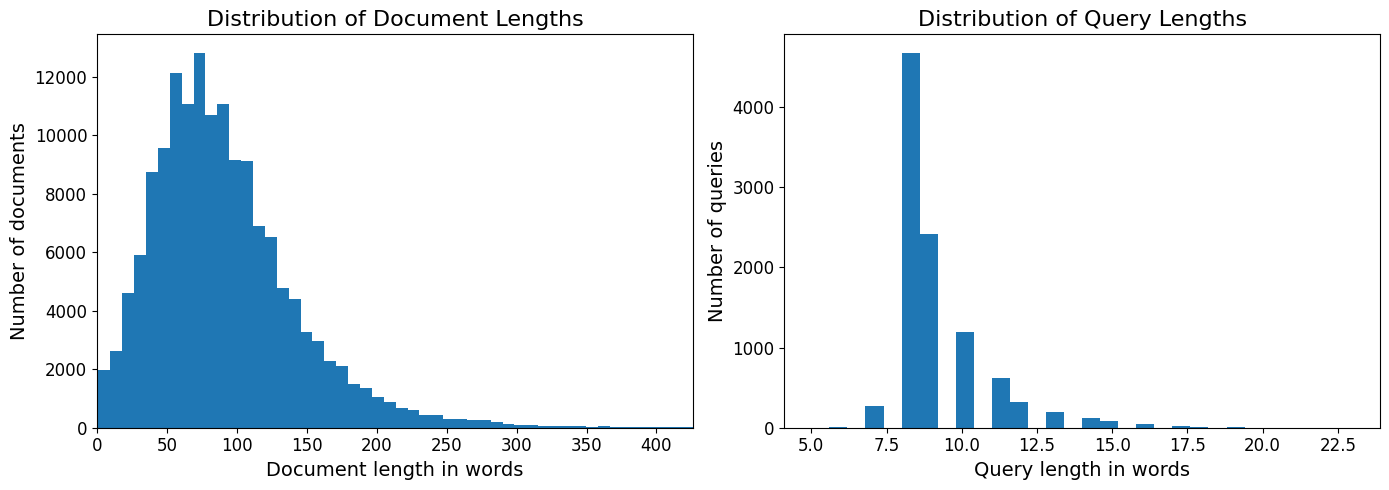

Maximum document length: 2219 words
99.9th percentile document length: 426 words


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use a slightly less aggressive cutoff
doc_xmax = doc_lengths.quantile(0.999)

# Keep only documents inside the displayed range
doc_lengths_plot = doc_lengths[doc_lengths <= doc_xmax]

# Font sizes
title_size = 16
label_size = 14
tick_size = 12

# Document length distribution
axes[0].hist(doc_lengths_plot, bins=50)
axes[0].set_xlim(0, doc_xmax)
axes[0].set_title("Distribution of Document Lengths", fontsize=title_size)
axes[0].set_xlabel("Document length in words", fontsize=label_size)
axes[0].set_ylabel("Number of documents", fontsize=label_size)
axes[0].tick_params(axis="both", labelsize=tick_size)

# Query length distribution
axes[1].hist(query_lengths, bins=30)
axes[1].set_title("Distribution of Query Lengths", fontsize=title_size)
axes[1].set_xlabel("Query length in words", fontsize=label_size)
axes[1].set_ylabel("Number of queries", fontsize=label_size)
axes[1].tick_params(axis="both", labelsize=tick_size)

plt.tight_layout()
plt.show()

print(f"Maximum document length: {doc_lengths.max():.0f} words")
print(f"99.9th percentile document length: {doc_xmax:.0f} words")

# 2.2 Indexing

The objective of this section is to help you build the index of your search engine. The following tasks should be completed:
* Load and index the dataset.
* You should build four different versions of your index: (1) full index, (2) stopwords removed, (3) stemming, (4) stopwords removed + stemming.

### Build Indexes

In [7]:
index_path_default = "./indexes/default"
index_path_default_obj = Path(index_path_default)

if (index_path_default_obj / "data.properties").exists():
    print(f"Default index already exists at {index_path_default}. Loading without rebuilding.")

    index_ref = index_path_default
    index = pt.IndexFactory.of(index_ref)

else:
    print(f"Default index does not exist at {index_path_default}. Building index.")

    indexer = pt.IterDictIndexer(index_path_default, overwrite=True)
    index_ref = indexer.index(docs.to_dict(orient="records"))
    index = pt.IndexFactory.of(index_ref)

    print(f"Built default index at {index_path_default}")

print("Default index statistics:")
print(index.getCollectionStatistics().toString())

Default index already exists at ./indexes/default. Loading without rebuilding.
Default index statistics:
Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false



### 2.2.1 Full Index

In [8]:
index_path_none = "./indexes/full"
index_path_none_obj = Path(index_path_none)

build_time_path_none = index_path_none_obj / "build_time.json"

if index_path_none_obj.exists():
    print(f"Index already exists at {index_path_none}. Loading without rebuilding.")

    index_none = pt.IndexFactory.of(index_path_none)

    if build_time_path_none.exists():
        with open(build_time_path_none, "r") as f:
            build_time_index_none = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_none:.2f}s")
    else:
        build_time_index_none = None
        print("No preserved build time found.")

else:
    print(f"Index does not exist at {index_path_none}. Building index.")

    start_time_index_none = time.perf_counter()

    indexer_none = pt.IterDictIndexer(
        index_path_none,
        overwrite=True,
        stopwords=None,
        stemmer=None
    )

    index_ref_none = indexer_none.index(docs.to_dict(orient="records"))
    index_none = pt.IndexFactory.of(index_ref_none)

    end_time_index_none = time.perf_counter()
    build_time_index_none = end_time_index_none - start_time_index_none

    with open(build_time_path_none, "w") as f:
        json.dump(
            {
                "description": "Full index",
                "build_time_milliseconds": build_time_index_none
            },
            f,
            indent=4
        )

    print(f"Built index and saved build time: {build_time_index_none:.2f}s")

# Validate loaded/built index
stats_stop = index_none.getCollectionStatistics()

Index already exists at ./indexes/full. Loading without rebuilding.
Loaded preserved build time: 31.61s


### 2.2.2 Stopwords removed

In [9]:
index_path_stop = "./indexes/stopwords"
index_path_stop_obj = Path(index_path_stop)

build_time_path_stop = index_path_stop_obj / "build_time.json"

if (index_path_stop_obj / "data.properties").exists():
    print(f"Stopwords index already exists at {index_path_stop}. Loading without rebuilding.")

    index_stop = pt.IndexFactory.of(index_path_stop)

    if build_time_path_stop.exists():
        with open(build_time_path_stop, "r") as f:
            build_time_index_stop = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stop:.2f}s")
    else:
        build_time_index_stop = None
        print("No preserved build time found.")

else:
    print(f"Stopwords index does not exist at {index_path_stop}. Building index.")

    start_time_index_stop = time.perf_counter()

    indexer_stop = pt.IterDictIndexer(
        index_path_stop,
        overwrite=True,
        stopwords="terrier",
        stemmer=None
    )

    index_ref_stop = indexer_stop.index(docs.to_dict(orient="records"))
    index_stop = pt.IndexFactory.of(index_ref_stop)

    end_time_index_stop = time.perf_counter()
    build_time_index_stop = end_time_index_stop - start_time_index_stop

    with open(build_time_path_stop, "w") as f:
        json.dump(
            {
                "description": "Stopwords removed, no stemming",
                "build_time_milliseconds": build_time_index_stop
            },
            f,
            indent=4
        )

    print(f"Built stopwords index and saved build time: {build_time_index_stop:.2f}s")

# Validate loaded/built index
stats_stop = index_stop.getCollectionStatistics()

Stopwords index already exists at ./indexes/stopwords. Loading without rebuilding.
Loaded preserved build time: 24.25s


### 2.2.3 Stemming

In [10]:
index_path_stem = "./indexes/stemming"
index_path_stem_obj = Path(index_path_stem)

build_time_path_stem = index_path_stem_obj / "build_time.json"

if (index_path_stem_obj / "data.properties").exists():
    print(f"Stemming index already exists at {index_path_stem}. Loading without rebuilding.")

    index_stem = pt.IndexFactory.of(index_path_stem)

    if build_time_path_stem.exists():
        with open(build_time_path_stem, "r") as f:
            build_time_index_stem = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stem:.2f}s")
    else:
        build_time_index_stem = None
        print("No preserved build time found.")

else:
    print(f"Stemming index does not exist at {index_path_stem}. Building index.")

    start_time_index_stem = time.perf_counter()

    indexer_stem = pt.IterDictIndexer(
        index_path_stem,
        overwrite=True,
        stopwords=None,
        stemmer="porter"
    )

    index_ref_stem = indexer_stem.index(docs.to_dict(orient="records"))
    index_stem = pt.IndexFactory.of(index_ref_stem)

    end_time_index_stem = time.perf_counter()
    build_time_index_stem = end_time_index_stem - start_time_index_stem

    with open(build_time_path_stem, "w") as f:
        json.dump(
            {
                "description": "No stopwords removed, Porter stemming",
                "build_time_milliseconds": build_time_index_stem
            },
            f,
            indent=4
        )

    print(f"Built stemming index and saved build time: {build_time_index_stem:.2f}s")

# Validate loaded/built index
stats_stem = index_stem.getCollectionStatistics()

Stemming index already exists at ./indexes/stemming. Loading without rebuilding.
Loaded preserved build time: 26.73s


### 2.2.4 Stopwords and Stemming

In [11]:
index_path_stop_stem = "./indexes/stop-stem"
index_path_stop_stem_obj = Path(index_path_stop_stem)

build_time_path_stop_stem = index_path_stop_stem_obj / "build_time.json"

if (index_path_stop_stem_obj / "data.properties").exists():
    print(f"Stopwords + stemming index already exists at {index_path_stop_stem}. Loading without rebuilding.")

    index_stop_stem = pt.IndexFactory.of(index_path_stop_stem)

    if build_time_path_stop_stem.exists():
        with open(build_time_path_stop_stem, "r") as f:
            build_time_index_stop_stem = json.load(f)["build_time_milliseconds"]

        print(f"Loaded preserved build time: {build_time_index_stop_stem:.2f}s")
    else:
        build_time_index_stop_stem = None
        print("No preserved build time found.")

else:
    print(f"Stopwords + stemming index does not exist at {index_path_stop_stem}. Building index.")

    start_time_index_stop_stem = time.perf_counter()

    indexer_stop_stem = pt.IterDictIndexer(
        index_path_stop_stem,
        overwrite=True,
        stopwords="terrier",
        stemmer="porter"
    )

    index_ref_stop_stem = indexer_stop_stem.index(docs.to_dict(orient="records"))
    index_stop_stem = pt.IndexFactory.of(index_ref_stop_stem)

    end_time_index_stop_stem = time.perf_counter()
    build_time_index_stop_stem = end_time_index_stop_stem - start_time_index_stop_stem

    with open(build_time_path_stop_stem, "w") as f:
        json.dump(
            {
                "description": "Stopwords removed, Porter stemming",
                "build_time_milliseconds": build_time_index_stop_stem
            },
            f,
            indent=4
        )

    print(f"Built stopwords + stemming index and saved build time: {build_time_index_stop_stem:.2f}s")

# Validate loaded/built index
stats_stop_stem = index_stop_stem.getCollectionStatistics()

Stopwords + stemming index already exists at ./indexes/stop-stem. Loading without rebuilding.
Loaded preserved build time: 24.78s


### Helpers

In [12]:
# Helper: calculate index folder size
def get_folder_size_mb(path):
    total_size = 0

    for dirpath, _, filenames in os.walk(path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            if os.path.isfile(filepath):
                total_size += os.path.getsize(filepath)

    return total_size / (1024 ** 2)

In [13]:
# Helper: calculate average search time
def get_average_search_time(index, queries_df, wmodel="BM25", sample_size=2000):
    sample = queries_df.sample(min(sample_size, len(queries_df)), random_state=42)
    retriever = pt.terrier.Retriever(index, wmodel=wmodel)
    times_ms = []
    for _, row in sample.iterrows():
        q = pd.DataFrame([{"qid": str(row["qid"]), "query": row["text"]}])
        start = time.perf_counter()
        _ = retriever.transform(q)
        times_ms.append((time.perf_counter() - start) * 1000)

    return sum(times_ms) / len(times_ms)


In [14]:
# Helper
def read_build_time(index_path):
    build_time_path = Path(index_path) / "build_time.json"

    if not build_time_path.exists():
        return None

    with open(build_time_path, "r") as file:
        return round(json.load(file)["build_time_milliseconds"], 1)

### Index Statistics

In [15]:
indexes = {
    "Full": index_none,
    "Stopwords removed": index_stop,
    "Stemming only": index_stem,
    "Stopwords + stemming": index_stop_stem
}

rows = []

for name, index in indexes.items():
    stats = index.getCollectionStatistics()

    rows.append({
        "Index": name,
        "Documents": stats.getNumberOfDocuments(),
        "Terms": stats.getNumberOfUniqueTerms(),
        "Tokens": stats.getNumberOfTokens(),
        "Postings": stats.getNumberOfPointers(),
        "Fields": stats.getNumberOfFields()
    })

stats_table = pd.DataFrame(rows)
stats_table

,Index,Documents,Terms,Tokens,Postings,Fields
0,Full,151993,160176,14483146,9518322,0
1,Stopwords removed,151993,159671,8423338,6605870,0
2,Stemming only,151993,124796,14483146,9263034,0
3,Stopwords + stemming,151993,124533,8423338,6389931,0


In [16]:
report_cache_path = Path("./results/report_table_rows.json")

if report_cache_path.exists():
    print(f"Loading cached report table rows from {report_cache_path}")

    with open(report_cache_path, "r") as file:
        rows = json.load(file)

else:
    print("No cached report table found. Computing report table rows...")

    rows = []

    for index_name, index_info in indexes.items(a):
        index = index_info["index"]
        stats = index.getCollectionStatistics()

        print(f"Computing: {index_name}...")

        rows.append({
            "Index version": index_name,
            "Description": index_info["description"],
            "Number of documents indexed": stats.getNumberOfDocuments(),
            "Number of unique terms": stats.getNumberOfUniqueTerms(),
            "Total number of tokens": stats.getNumberOfTokens(),
            "Index storage size (MB)": round(get_folder_size_mb(index_info["path"]), 1),
            "Build time (seconds)": index_info["build_time"],
            "Average search time per query (milli-seconds)": round(get_average_search_time(index, train_queries), 3)
        })

    with open(report_cache_path, "w") as file:
        json.dump(rows, file, indent=4)

    print(f"Saved report table rows to {report_cache_path}")

table = pd.DataFrame(rows)
table

Loading cached report table rows from results/report_table_rows.json


,Index version,Description,Number of documents indexed,Number of unique terms,Total number of tokens,Index storage size (MB),Build time (seconds),Average search time per query (milli-seconds)
0,index_none,"No stopword removal, no stemming",151993,160176,14483146,59.7,31.6,70.916
1,index_stop,Stopword removal only,151993,159671,8423338,54.4,24.2,34.775
2,index_stem,Stemming only,151993,124796,14483146,53.8,26.7,71.328
3,index_stop_stem,Stopword removal and stemming,151993,124533,8423338,48.7,24.8,33.952
